In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/raw/Dataset.csv')
df.shape

(1552210, 44)

In [3]:
df.head()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [4]:
df['Patient_ID'].nunique()

40336

In [5]:
df['SepsisLabel'].value_counts()

SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64

In [6]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct.sort_values(ascending=False)

Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
BUN                 93.134434
pH                  93.069688
Hgb                 92.617558
FiO2                91.665754
Hct                 91.145979
Potassium           90.689082
Glucose             82.894325
Temp                66.162697
Unit2               39.425078
Unit1               39.425078
DBP                 31.345887
Resp                15.354559
SBP                 14.576958
O2Sat     

In [7]:
pd.set_option('display.max_rows', None)
missing_pct.sort_values(ascending=False)

Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
BUN                 93.134434
pH                  93.069688
Hgb                 92.617558
FiO2                91.665754
Hct                 91.145979
Potassium           90.689082
Glucose             82.894325
Temp                66.162697
Unit2               39.425078
Unit1               39.425078
DBP                 31.345887
Resp                15.354559
SBP                 14.576958
O2Sat     

In [8]:
print(missing_pct.sort_values(ascending=False).to_string())

Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
BUN                 93.134434
pH                  93.069688
Hgb                 92.617558
FiO2                91.665754
Hct                 91.145979
Potassium           90.689082
Glucose             82.894325
Temp                66.162697
Unit2               39.425078
Unit1               39.425078
DBP                 31.345887
Resp                15.354559
SBP                 14.576958
O2Sat     

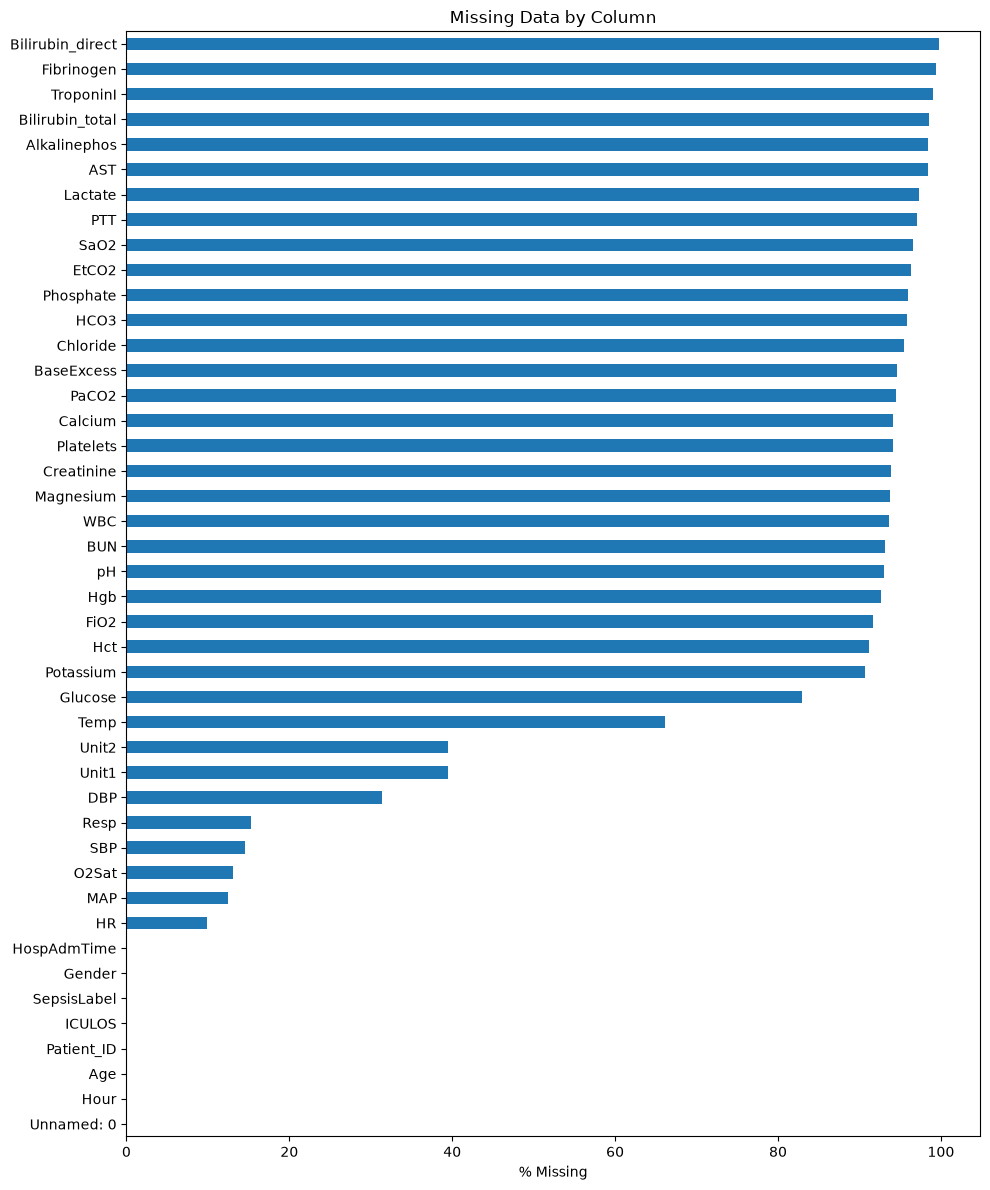

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
missing_pct.sort_values().plot(kind='barh')
plt.xlabel('% Missing')
plt.title('Missing Data by Column')
plt.tight_layout()
plt.savefig('../figures/missing_data_by_column.png')
plt.show()

In [10]:
patients_with_sepsis = df[df['SepsisLabel'] == 1]['Patient_ID'].nunique()
total_patients = df['Patient_ID'].nunique()
print(f"Patients who developed sepsis: {patients_with_sepsis} out of {total_patients}")
print(f"Percentage: {patients_with_sepsis/total_patients*100:.2f}%")

Patients who developed sepsis: 2932 out of 40336
Percentage: 7.27%


In [11]:
df.groupby('SepsisLabel')[['HR', 'Temp', 'Resp', 'MAP']].mean()

,HR,Temp,Resp,MAP
SepsisLabel,,,,
0,84.465334,36.972202,18.694357,82.442375
1,90.785245,37.250813,20.460376,80.168490


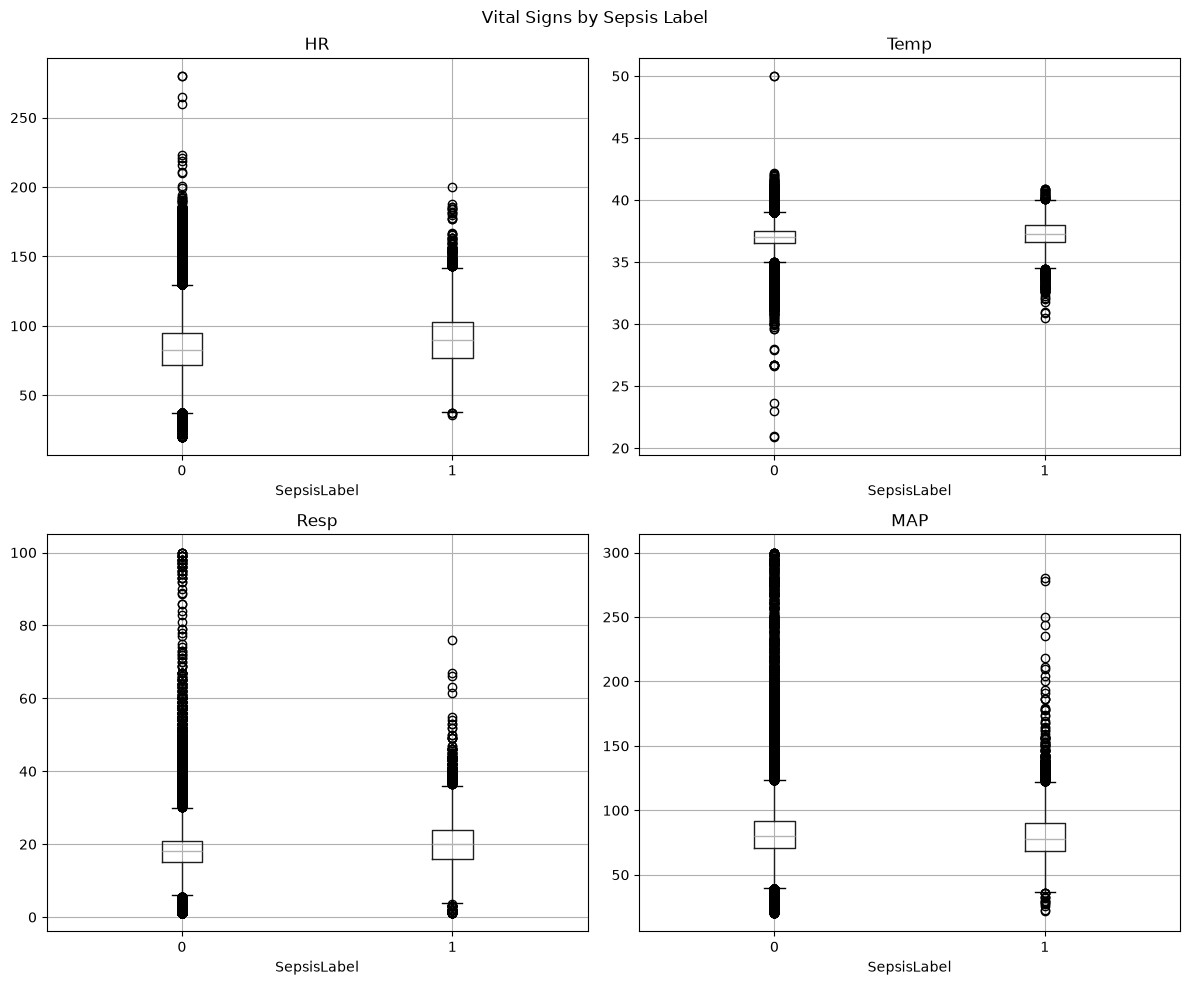

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), ['HR', 'Temp', 'Resp', 'MAP']):
    df.boxplot(column=col, by='SepsisLabel', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('SepsisLabel')

plt.suptitle('Vital Signs by Sepsis Label')
plt.tight_layout()
plt.savefig('../figures/vitals_boxplot_by_sepsis.png')
plt.show()

In [13]:
vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']

labs = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
        'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
        'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
        'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
        'Fibrinogen', 'Platelets']

static = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime']

print(f"Vitals: {len(vitals)}, Labs: {len(labs)}, Static: {len(static)}")
print(f"Total: {len(vitals) + len(labs) + len(static)} (+ ICULOS + SepsisLabel + Patient_ID)")

Vitals: 8, Labs: 26, Static: 5
Total: 39 (+ ICULOS + SepsisLabel + Patient_ID)


In [14]:
vitals_agg = df.groupby('Patient_ID')[vitals].agg(['mean', 'min', 'max'])
vitals_agg.columns = ['_'.join(col) for col in vitals_agg.columns]
vitals_agg.head()

,HR_mean,HR_min,HR_max,O2Sat_mean,O2Sat_min,O2Sat_max,Temp_mean,Temp_min,Temp_max,SBP_mean,...,MAP_max,DBP_mean,DBP_min,DBP_max,Resp_mean,Resp_min,Resp_max,EtCO2_mean,EtCO2_min,EtCO2_max
Patient_ID,,,,,,,,,,,,,,,,,,,,,
1,101.571429,76.0,117.0,91.477273,85.0,100.0,36.778000,36.11,37.44,126.809524,...,141.33,NaN,NaN,NaN,24.820000,17.0,32.0,NaN,NaN,NaN
2,60.954545,54.0,94.0,97.000000,94.0,100.0,36.165000,36.00,36.44,136.600000,...,116.00,44.066667,36.0,66.0,14.236842,9.0,27.0,NaN,NaN,NaN
3,79.611111,68.0,93.0,95.431818,91.0,99.0,37.609375,36.89,38.61,140.033333,...,99.00,54.392857,44.0,69.0,25.633333,17.0,40.0,NaN,NaN,NaN
4,102.444444,93.0,113.0,98.203704,95.5,100.0,36.455000,36.06,36.78,113.019231,...,84.00,51.428571,44.0,61.5,18.884615,14.0,26.0,NaN,NaN,NaN
5,73.916667,61.0,88.0,97.500000,96.0,99.0,36.992222,36.22,37.33,132.770833,...,103.00,NaN,NaN,NaN,16.500000,14.0,21.0,NaN,NaN,NaN


In [15]:
labs_agg = df.groupby('Patient_ID')[labs].last()
labs_agg = labs_agg.add_suffix('_last')
labs_agg.head()

,BaseExcess_last,HCO3_last,FiO2_last,pH_last,PaCO2_last,SaO2_last,AST_last,BUN_last,Alkalinephos_last,Calcium_last,...,Phosphate_last,Potassium_last,Bilirubin_total_last,TroponinI_last,Hct_last,Hgb_last,PTT_last,WBC_last,Fibrinogen_last,Platelets_last
Patient_ID,,,,,,,,,,,,,,,,,,,,,
1,19.0,48.0,0.25,7.32,100.0,89.0,16.0,22.0,98.0,9.6,...,3.7,4.6,0.3,NaN,36.2,12.2,NaN,14.7,NaN,338.0
2,NaN,22.0,NaN,NaN,NaN,NaN,NaN,100.0,NaN,7.9,...,4.4,5.1,NaN,NaN,27.8,9.7,NaN,11.0,NaN,158.0
3,5.0,29.0,0.80,7.49,38.0,NaN,NaN,25.0,NaN,11.0,...,2.9,4.1,NaN,NaN,32.1,11.0,29.5,8.7,NaN,486.0
4,0.0,22.0,NaN,7.41,41.0,98.0,NaN,19.0,NaN,8.2,...,3.8,4.3,NaN,NaN,24.0,8.3,22.3,7.6,NaN,144.0
5,NaN,25.0,NaN,NaN,NaN,NaN,30.0,9.0,80.0,8.5,...,3.0,4.0,0.6,NaN,45.7,15.5,29.0,4.7,NaN,288.0


In [16]:
static_agg = df.groupby('Patient_ID')[static].first()
other_agg = df.groupby('Patient_ID').agg(ICULOS_max=('ICULOS', 'max'), SepsisLabel=('SepsisLabel', 'max'))

static_agg.head()

,Age,Gender,Unit1,Unit2,HospAdmTime
Patient_ID,,,,,
1,83.14,0,NaN,NaN,-0.03
2,75.91,0,0.0,1.0,-98.60
3,45.82,0,1.0,0.0,-1195.71
4,65.71,0,0.0,1.0,-8.77
5,28.09,1,1.0,0.0,-0.05


In [17]:
patient_df = pd.concat([vitals_agg, labs_agg, static_agg, other_agg], axis=1)
patient_df.shape

(40336, 57)

In [18]:
patient_df['SepsisLabel'].value_counts()

SepsisLabel
0    37404
1     2932
Name: count, dtype: int64

In [19]:
patient_df.to_csv('../data/processed/patient_level_data.csv')
print(f"Saved: {patient_df.shape[0]} patients, {patient_df.shape[1]} columns")

Saved: 40336 patients, 57 columns
